## Cell 1 — Install & Import Libraries

In [1]:
import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Upload & Extract Your Dataset

In [4]:
from google.colab import files

print('Upload your dataset ZIP file...')
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
print(f'Uploaded: {zip_name}')


with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/dataset_raw')

print('Extraction complete. Folder structure:')
for root, dirs, files_ in os.walk('/content/dataset_raw'):
    level = root.replace('/content/dataset_raw', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for f in files_[:3]:
            print(f'{indent}  {f}')
        if len(files_) > 3:
            print(f'{indent}  ... ({len(files_)} total files)')

Upload your dataset ZIP file...


Saving archive (1).zip to archive (1).zip
Uploaded: archive (1).zip
Extraction complete. Folder structure:
dataset_raw/
  train/
    cats/
      cat_544.jpg
      cat_414.jpg
      cat_2.jpg
      ... (279 total files)
    dogs/
      dog_262.jpg
      dog_277.jpg
      dog_32.jpg
      ... (278 total files)
  test/
    cats/
      cat_523.jpg
      cat_203.jpg
      cat_583.jpg
      ... (70 total files)
    dogs/
      dog_521.jpg
      dog_462.jpg
      dog_142.jpg
      ... (70 total files)


## Cell 3a — Set Dataset Paths (if already split into train/test)

In [5]:

TRAIN_DIR = '/content/dataset_raw/train'
TEST_DIR  = '/content/dataset_raw/test'
for split, path in [('Train', TRAIN_DIR), ('Test', TEST_DIR)]:
    cats = len(os.listdir(os.path.join(path, 'cats')))
    dogs = len(os.listdir(os.path.join(path, 'dogs')))
    print(f'{split}: {cats} cats, {dogs} dogs')

Train: 279 cats, 278 dogs
Test: 70 cats, 70 dogs


## Cell 3b — Auto-Split (use this if you have ONE folder of mixed images)

In [6]:


RAW_DIR   = '/content/dataset_raw'
TRAIN_DIR = '/content/data/train'
TEST_DIR  = '/content/data/test'
SPLIT     = 0.8

for cls in ['cats', 'dogs']:
    os.makedirs(f'{TRAIN_DIR}/{cls}', exist_ok=True)
    os.makedirs(f'{TEST_DIR}/{cls}', exist_ok=True)

def split_and_copy(src_folder, class_name, keyword):
    imgs = [f for f in os.listdir(src_folder)
            if keyword in f.lower() and f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(imgs)
    cut = int(len(imgs) * SPLIT)
    for i, f in enumerate(imgs):
        dst = TRAIN_DIR if i < cut else TEST_DIR
        shutil.copy(os.path.join(src_folder, f), f'{dst}/{class_name}/{f}')
    print(f'{class_name}: {cut} train, {len(imgs)-cut} test')

split_and_copy(RAW_DIR, 'cats', 'cat')
split_and_copy(RAW_DIR, 'dogs', 'dog')
print('Split complete!')

cats: 0 train, 0 test
dogs: 0 train, 0 test
Split complete!


## Cell 4 — Configuration

In [7]:

IMG_SIZE    = (150, 150)
BATCH_SIZE  = 32
EPOCHS      = 20
LEARNING_RATE = 0.001
SEED        = 42

CLASS_NAMES = ['cats', 'dogs']
NUM_CLASSES = 2

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Config set:')
print(f'  Image size : {IMG_SIZE}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Epochs     : {EPOCHS}')
print(f'  Classes    : {CLASS_NAMES}')

Config set:
  Image size : (150, 150)
  Batch size : 32
  Epochs     : 20
  Classes    : ['cats', 'dogs']


## Cell 5 — Data Augmentation & Generators

In [8]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

print(f'Class indices: {train_gen.class_indices}')

Found 0 images belonging to 2 classes.
Found 0 images belonging to 2 classes.
Class indices: {'cats': 0, 'dogs': 1}


## Cell 6 — Visualize Sample Images

Found 557 images belonging to 2 classes.
Re-initialized train_gen with the correct TRAIN_DIR.


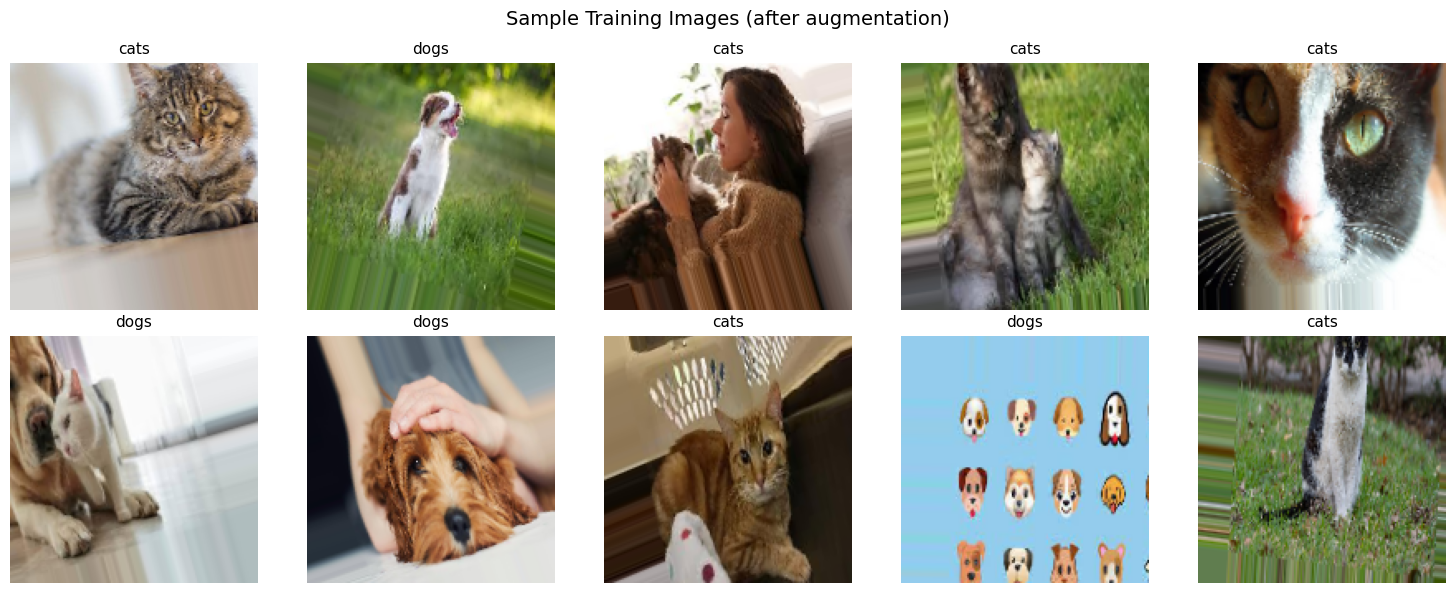

In [9]:
TRAIN_DIR = '/content/dataset_raw/train'

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    seed=SEED
)
print("Re-initialized train_gen with the correct TRAIN_DIR.")


imgs, labels = next(train_gen)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Training Images (after augmentation)', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i])
    label_idx = np.argmax(labels[i])
    ax.set_title(CLASS_NAMES[label_idx], fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Cell 7 — Build the CNN Model

In [10]:
def build_cnn(input_shape, num_classes):
    model = models.Sequential([


        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape, name='conv1_1'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same', name='conv1_2'),
        layers.MaxPooling2D(2, 2, name='pool1'),
        layers.BatchNormalization(),


        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_1'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_2'),
        layers.MaxPooling2D(2, 2, name='pool2'),
        layers.BatchNormalization(),


        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3_1'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3_2'),
        layers.MaxPooling2D(2, 2, name='pool3'),
        layers.BatchNormalization(),


        layers.Flatten(name='flatten'),
        layers.Dense(512, activation='relu', name='fc1'),
        layers.Dropout(0.5, name='dropout1'),
        layers.Dense(256, activation='relu', name='fc2'),
        layers.Dropout(0.3, name='dropout2'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

model = build_cnn((*IMG_SIZE, 3), NUM_CLASSES)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 37, 37, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │    21,234,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,653,922 (82.60 MB)

 Trainable params: 21,653,474 (82.60 MB)

 Non-trainable params: 448 (1.75 KB)

## Cell 8 — Compile the Model

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


cb_list = [

    callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    ),

    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    ),

    callbacks.ModelCheckpoint(
        '/content/best_model.h5',
        monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]

print('Model compiled. Ready to train.')

Model compiled. Ready to train.


## Cell 9 — Train the Model

In [12]:
TEST_DIR = '/content/dataset_raw/test'
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)
print("Re-initialized test_gen with the correct TEST_DIR.")

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen,
    callbacks=cb_list,
    verbose=1
)

print(f'\nTraining complete. Best val_accuracy: {max(history.history["val_accuracy"]):.4f}')

Found 140 images belonging to 2 classes.
Re-initialized test_gen with the correct TEST_DIR.
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 873ms/step - accuracy: 0.5623 - loss: 3.7708
Epoch 1: val_accuracy improved from None to 0.51429, saving model to /content/best_model.h5



Epoch 1: finished saving model to /content/best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.5494 - loss: 4.0514 - val_accuracy: 0.5143 - val_loss: 0.7121 - learning_rate: 0.0010
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.5596 - loss: 4.2871
Epoch 2: val_accuracy did not improve from 0.51429
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 419ms/step - accuracy: 0.5422 - loss: 4.5019 - val_accuracy: 0.5000 - val_loss: 3.0311 - learning_rate: 0.0010
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.5408 - loss: 4.8628
Epoch 3: val_accuracy did not improve from 0.51429
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 406ms/step - accuracy: 0.5224 - loss: 4.1302 - val_accuracy: 0.4643 - val_loss: 1.0843 - learning_rate: 0.0010
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.5413 - loss: 2.7129
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy did not improve from 0.51429
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 442


Epoch 6: finished saving model to /content/best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 484ms/step - accuracy: 0.5440 - loss: 1.5803 - val_accuracy: 0.5429 - val_loss: 0.7397 - learning_rate: 5.0000e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.

Training complete. Best val_accuracy: 0.5429


## Cell 10 — Plot Training Curves

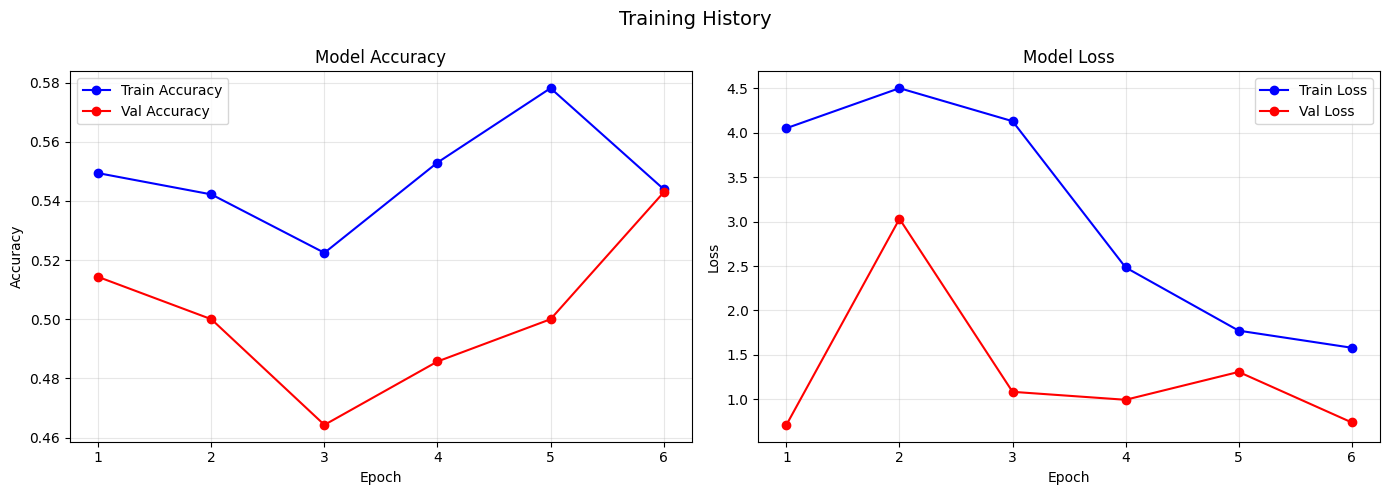

Saved to /content/training_curves.png


In [13]:
acc     = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss    = history.history['loss']
val_loss= history.history['val_loss']
epochs_ran = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, acc,     'b-o', label='Train Accuracy')
ax1.plot(epochs_ran, val_acc, 'r-o', label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ran, loss,     'b-o', label='Train Loss')
ax2.plot(epochs_ran, val_loss, 'r-o', label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to /content/training_curves.png')

## Cell 11 — Evaluate on Test Set

In [14]:
test_gen.reset()
loss, accuracy = model.evaluate(test_gen, verbose=1)
print(f'\nTest Loss     : {loss:.4f}')
print(f'Test Accuracy : {accuracy*100:.2f}%')

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.5143 - loss: 0.7121

Test Loss     : 0.7121
Test Accuracy : 51.43%


## Cell 12 — Confusion Matrix & Classification Report

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 273ms/step

Classification Report:
              precision    recall  f1-score   support

        cats       0.51      0.57      0.54        70
        dogs       0.52      0.46      0.48        70

    accuracy                           0.51       140
   macro avg       0.51      0.51      0.51       140
weighted avg       0.51      0.51      0.51       140



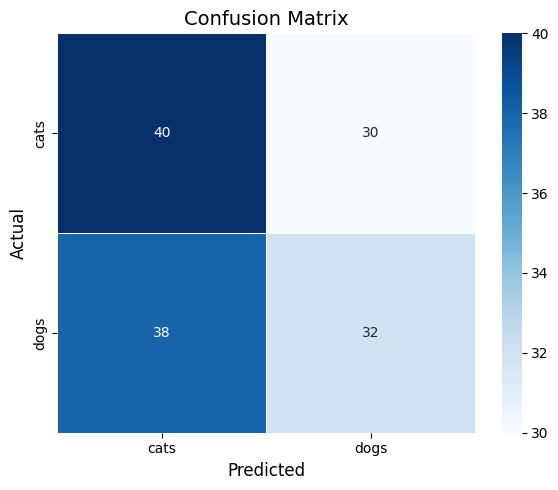

Saved to /content/confusion_matrix.png


In [15]:
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Classification report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to /content/confusion_matrix.png')

## Cell 13 — Visualize Predictions on Test Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 618ms/step


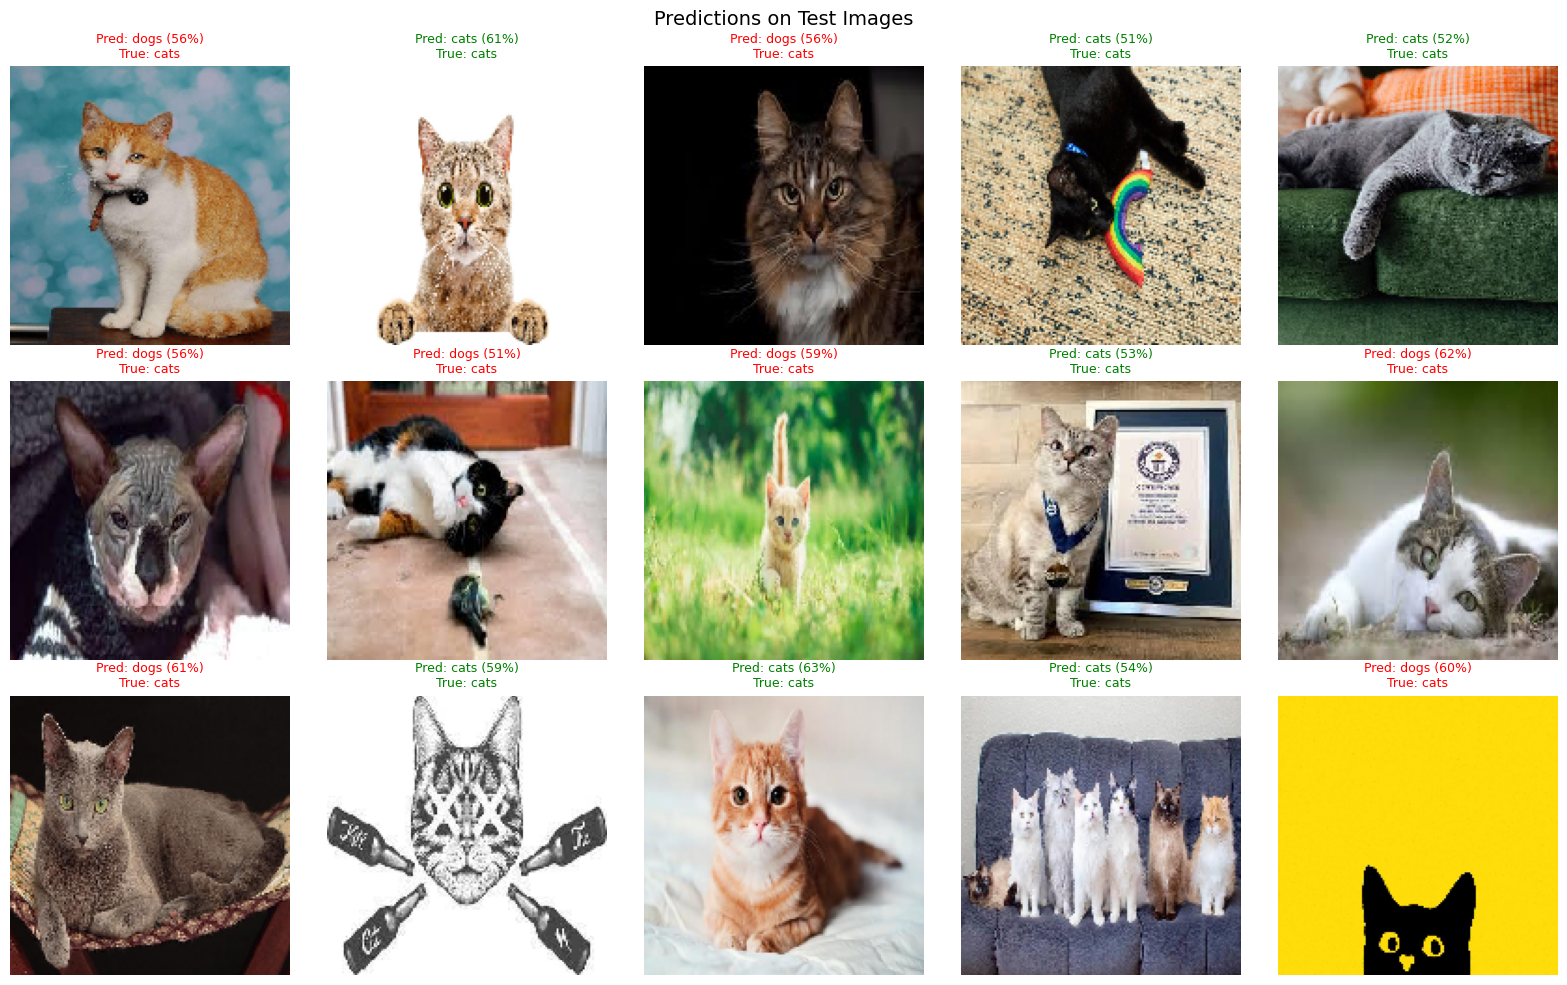

Saved to /content/predictions.png


In [16]:
test_gen.reset()
sample_imgs, sample_labels = next(test_gen)
preds = model.predict(sample_imgs)

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
fig.suptitle('Predictions on Test Images', fontsize=14)

for i, ax in enumerate(axes.flat):
    if i >= len(sample_imgs):
        ax.axis('off')
        continue
    ax.imshow(sample_imgs[i])
    true_label = CLASS_NAMES[np.argmax(sample_labels[i])]
    pred_label = CLASS_NAMES[np.argmax(preds[i])]
    conf = np.max(preds[i]) * 100
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f'Pred: {pred_label} ({conf:.0f}%)\nTrue: {true_label}',
                 color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to /content/predictions.png')

## Cell 14 — Predict on a Single New Image

Upload a single cat or dog image to test:


Saving cat_60.jpg to cat_60.jpg


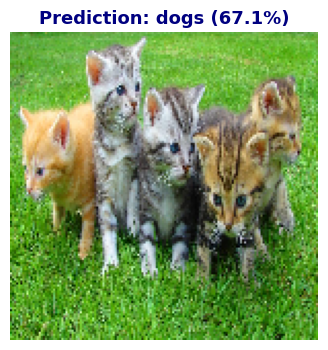

  Cat: 32.9%
  Dog: 67.1%


('dogs', np.float32(67.079834))

In [17]:
from tensorflow.keras.preprocessing import image as keras_image
import numpy as np # Required for np.expand_dims and np.argmax
import matplotlib.pyplot as plt # Required for plt.figure, plt.imshow, etc.
import tensorflow as tf # Required for tf.keras.models.load_model

# Define configuration variables needed by this cell
IMG_SIZE = (150, 150)
CLASS_NAMES = ['cats', 'dogs']

def predict_image(img_path, model, class_names, img_size=(150,150)):
    img = keras_image.load_img(img_path, target_size=img_size)
    arr = keras_image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    probs = model.predict(arr, verbose=0)[0]
    pred_idx = np.argmax(probs)
    label = class_names[pred_idx]
    confidence = probs[pred_idx] * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(keras_image.load_img(img_path, target_size=img_size))
    plt.title(f'Prediction: {label} ({confidence:.1f}%)', fontsize=13,
              color='navy', fontweight='bold')
    plt.axis('off')
    plt.show()

    print(f'  Cat: {probs[0]*100:.1f}%')
    print(f'  Dog: {probs[1]*100:.1f}%')
    return label, confidence

# ── Upload a single image to test ────────────────────────────
from google.colab import files as colab_files
print('Upload a single cat or dog image to test:')
uploaded_img = colab_files.upload()
img_path = list(uploaded_img.keys())[0]

# Load the best model saved during training to ensure it's defined
model = tf.keras.models.load_model('/content/best_model.h5')

predict_image(img_path, model, CLASS_NAMES, IMG_SIZE)

## Cell 15 — Save & Download the Model

In [18]:

model.save('/content/cat_dog_cnn_final.h5')
print('Model saved to /content/cat_dog_cnn_final.h5')


model.export('/content/cat_dog_cnn_savedmodel')
print('SavedModel saved to /content/cat_dog_cnn_savedmodel/')


from google.colab import files as colab_files
colab_files.download('/content/cat_dog_cnn_final.h5')
print('Download started!')

Model saved to /content/cat_dog_cnn_final.h5
Saved artifact at '/content/cat_dog_cnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136302432271632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136301132664656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136301132663504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136301132666768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136301132665808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136301132662928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136301132663312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136301132664464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136301132664272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136301132665424: TensorSp

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!


In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import callbacks
import os


TRAIN_DIR = '/content/dataset_raw/train'
TEST_DIR  = '/content/dataset_raw/test'
IMG_SIZE  = (150, 150)
BATCH_SIZE = 32
NUM_CLASSES = 2


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical'
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)


cb_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('/content/best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1) # Fixed: Added closing parenthesis and missing arguments
]


Found 557 images belonging to 2 classes.
Found 140 images belonging to 2 classes.


## Cell 16 — (Optional) Transfer Learning with MobileNetV2

In [20]:


from tensorflow import keras
from tensorflow.keras import models, layers


IMG_SIZE = (150, 150)
NUM_CLASSES = 2

base_model = keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()


print('Training classifier head...')
transfer_model.fit(
    train_gen, epochs=10,
    validation_data=test_gen,
    callbacks=cb_list
)


base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Fine-tuning top layers...')
transfer_model.fit(
    train_gen, epochs=10,
    validation_data=test_gen,
    callbacks=cb_list
)

loss, acc = transfer_model.evaluate(test_gen)
print(f'\nTransfer Learning Test Accuracy: {acc*100:.2f}%')

/tmp/ipykernel_1963/3252673429.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,434 (9.87 MB)

...


Epoch 2: finished saving model to /content/best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 452ms/step - accuracy: 0.8510 - loss: 0.3520 - val_accuracy: 0.9000 - val_loss: 0.2175 - learning_rate: 0.0010
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.8894 - loss: 0.2177
Epoch 3: val_accuracy improved from 0.90000 to 0.92143, saving model to /content/best_model.h5



Epoch 3: finished saving model to /content/best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 389ms/step - accuracy: 0.8977 - loss: 0.2368 - val_accuracy: 0.9214 - val_loss: 0.1779 - learning_rate: 0.0010
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.9001 - loss: 0.2466
Epoch 4: val_accuracy did not improve from 0.92143
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 434ms/step - accuracy: 0.9156 - loss: 0.2024 - val_accuracy: 0.9071 - val_loss: 0.2158 - learning_rate: 0.0010
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.9131 - loss: 0.2037
Epoch 5: val_accuracy improved from 0.92143 to 0.94286, saving model to /content/best_model.h5



Epoch 5: finished saving model to /content/best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 406ms/step - accuracy: 0.9264 - loss: 0.1988 - val_accuracy: 0.9429 - val_loss: 0.1527 - learning_rate: 0.0010
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9359 - loss: 0.1755
Epoch 6: val_accuracy improved from 0.94286 to 0.95000, saving model to /content/best_model.h5



Epoch 6: finished saving model to /content/best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 417ms/step - accuracy: 0.9300 - loss: 0.1815 - val_accuracy: 0.9500 - val_loss: 0.1645 - learning_rate: 0.0010
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.9441 - loss: 0.1298
Epoch 7: val_accuracy did not improve from 0.95000
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 426ms/step - accuracy: 0.9497 - loss: 0.1337 - val_accuracy: 0.9214 - val_loss: 0.1894 - learning_rate: 0.0010
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.9428 - loss: 0.1340
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 8: val_accuracy did not improve from 0.95000
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 367ms/step - accuracy: 0.9479 - loss: 0.1347 - val_accuracy: 0.9357 - val_loss: 0.1844 - learning_rate: 0.0010
Epoch 9/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9478 - loss: 0.1110
Epoch 9: val_accuracy did not improve from 0.95000
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 4


Epoch 10: finished saving model to /content/best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 380ms/step - accuracy: 0.9605 - loss: 0.0945 - val_accuracy: 0.9571 - val_loss: 0.1564 - learning_rate: 5.0000e-04
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.
Fine-tuning top layers...
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.8400 - loss: 0.3378
Epoch 1: val_accuracy did not improve from 0.95714
18/18 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8294 - loss: 0.3521 - val_accuracy: 0.9500 - val_loss: 0.1470 - learning_rate: 1.0000e-05
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.8712 - loss: 0.2891
Epoch 2: val_accuracy did not improve from 0.95714
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 366ms/step - accuracy: 0.8833 - loss: 0.2809 - val_accuracy: 0.9500 - val_loss: 0.1411 - learning_rate: 1.0000e-05
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.8898 - loss: 0.2605
Epoch 3: val_accuracy did not improve 

/tmp/ipykernel_1963/1939170622.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall("/content/pets")


Extracted images.tar.gz
Extracted annotations.tar.gz

Cat breeds found: 25 → ['american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'boxer', 'chihuahua', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'miniature_pinscher', 'newfoundland', 'pomeranian', 'pug', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']
Dog breeds found: 12 → ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx']

Training CAT breed classifier...
Found 3993 images belonging to 25 classes.
Found 997 images belonging to 25 classes.
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 119s 801ms/step - accuracy: 0.7303 - loss: 0.9446 - val_accuracy: 0.8526 - val_loss: 0.4703 - learning_rate: 0.0010
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 70s


Cat Breed Accuracy: 88.77%

Training DOG breed classifier...
Found 1920 images belonging to 12 classes.
Found 480 images belonging to 12 classes.
Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 50s 675ms/step - accuracy: 0.5807 - loss: 1.2943 - val_accuracy: 0.8146 - val_loss: 0.5765 - learning_rate: 0.0010
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.7738 - loss: 0.6795
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
60/60 ━━━━━━━━━━━━━━━━━━━━ 33s 552ms/step - accuracy: 0.7833 - loss: 0.6477 - val_accuracy: 0.8438 - val_loss: 0.4446 - learning_rate: 0.0010
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 34s 568ms/step - accuracy: 0.8229 - loss: 0.4848 - val_accuracy: 0.8438 - val_loss: 0.4222 - learning_rate: 5.0000e-04
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.8513 - loss: 0.4383
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
60/60 ━━━━━━━━━━━━━━━━━━━━ 37s 621ms/step - accuracy: 0.8500 - loss: 0.4332 -


Dog Breed Accuracy: 82.50%


Upload a cat or dog image to test the full pipeline:


Saving cat_234.jpg to cat_234.jpg


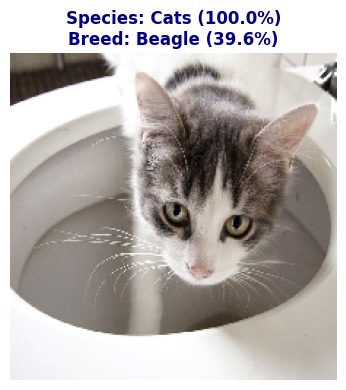

  Species : Cats (100.0%)
  Breed   : Beagle (39.6%)


('cats', 'Beagle')

In [21]:
## Cell 17 — Breed Classification (Two-Stage Pipeline)

import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import models, layers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import files as colab_files

# ── Step 1: Download Oxford-IIIT Pet Dataset (breed labels only) ──
import requests, tarfile, os

PET_URL = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
ANNOT_URL = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"

print("Downloading Oxford Pet Dataset...")
for url, fname in [(PET_URL, "images.tar.gz"), (ANNOT_URL, "annotations.tar.gz")]:
    r = requests.get(url, stream=True)
    with open(f"/content/{fname}", "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    with tarfile.open(f"/content/{fname}") as t:
        t.extractall("/content/pets")
    print(f"Extracted {fname}")

# ── Step 2: Organise into breed folders ──
import shutil
from pathlib import Path

IMG_DIR   = Path("/content/pets/images")
CAT_BREEDS = Path("/content/breed_data/cats")
DOG_BREEDS = Path("/content/breed_data/dogs")

# Oxford dataset: lowercase names = cats, Uppercase = dogs
for img_path in IMG_DIR.glob("*.jpg"):
    breed = "_".join(img_path.stem.split("_")[:-1])  # strip trailing number
    if breed[0].isupper():  # dog
        dest = DOG_BREEDS / breed
    else:                   # cat
        dest = CAT_BREEDS / breed
    dest.mkdir(parents=True, exist_ok=True)
    shutil.copy(img_path, dest / img_path.name)

cat_breeds = sorted(os.listdir(CAT_BREEDS))
dog_breeds = sorted(os.listdir(DOG_BREEDS))
print(f"\nCat breeds found: {len(cat_breeds)} → {cat_breeds}")
print(f"Dog breeds found: {len(dog_breeds)} → {dog_breeds}")

# ── Step 3: Build breed classifiers (one per species) ──
IMG_SIZE   = (224, 224)   # 224 for MobileNetV2
BATCH_SIZE = 32

def build_breed_model(num_breeds):
    base = keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_breeds, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def make_generators(data_dir):
    datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2
    )
    train_gen = datagen.flow_from_directory(
        data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', subset='training', seed=42
    )
    val_gen = datagen.flow_from_directory(
        data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', subset='validation', seed=42, shuffle=False
    )
    return train_gen, val_gen

cb = [
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

# ── Train cat breed model ──
print("\nTraining CAT breed classifier...")
cat_train, cat_val = make_generators(str(CAT_BREEDS))
cat_model = build_breed_model(len(cat_breeds))
cat_model.fit(cat_train, validation_data=cat_val, epochs=15, callbacks=cb)
cat_loss, cat_acc = cat_model.evaluate(cat_val)
print(f"\nCat Breed Accuracy: {cat_acc*100:.2f}%")
cat_model.save('/content/cat_breed_model.h5')

# ── Train dog breed model ──
print("\nTraining DOG breed classifier...")
dog_train, dog_val = make_generators(str(DOG_BREEDS))
dog_model = build_breed_model(len(dog_breeds))
dog_model.fit(dog_train, validation_data=dog_val, epochs=15, callbacks=cb)
dog_loss, dog_acc = dog_model.evaluate(dog_val)
print(f"\nDog Breed Accuracy: {dog_acc*100:.2f}%")
dog_model.save('/content/dog_breed_model.h5')

# ── Step 4: Two-stage pipeline — species first, then breed ──
from tensorflow.keras.preprocessing import image as keras_image

# Load your existing species classifier
species_model = keras.models.load_model('/content/best_model.h5')
SPECIES_NAMES = ['cats', 'dogs']

def predict_breed(img_path):
    # Stage 1 — cat or dog?
    img = keras_image.load_img(img_path, target_size=(150, 150))
    arr = keras_image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, 0)
    species_probs = species_model.predict(arr, verbose=0)[0]
    species = SPECIES_NAMES[np.argmax(species_probs)]
    species_conf = np.max(species_probs) * 100

    # Stage 2 — which breed?
    img2 = keras_image.load_img(img_path, target_size=(224, 224))
    arr2 = keras_image.img_to_array(img2) / 255.0
    arr2 = np.expand_dims(arr2, 0)

    if species == 'cats':
        breed_probs = cat_model.predict(arr2, verbose=0)[0]
        breed_names = cat_breeds
    else:
        breed_probs = dog_model.predict(arr2, verbose=0)[0]
        breed_names = dog_breeds

    breed = breed_names[np.argmax(breed_probs)].replace("_", " ").title()
    breed_conf = np.max(breed_probs) * 100

    # Display
    plt.figure(figsize=(4, 4))
    plt.imshow(keras_image.load_img(img_path, target_size=(224, 224)))
    plt.title(
        f"Species: {species.title()} ({species_conf:.1f}%)\nBreed: {breed} ({breed_conf:.1f}%)",
        fontsize=12, color='navy', fontweight='bold'
    )
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"  Species : {species.title()} ({species_conf:.1f}%)")
    print(f"  Breed   : {breed} ({breed_conf:.1f}%)")
    return species, breed

# ── Test it on a new image ──
print("Upload a cat or dog image to test the full pipeline:")
uploaded_img = colab_files.upload()
img_path = list(uploaded_img.keys())[0]
predict_breed(img_path)